In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
import pandas as pd

file_path = "../data/raw/online_retail_II.xlsx"

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [5]:
df1 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df2 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat([df1, df2], ignore_index=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df1 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df2 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat([df1, df2], ignore_index=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df["Sales"] = df["Quantity"] * df["Price"]

df[["Quantity", "Price", "Sales"]].head()

,Quantity,Price,Sales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Sales
count,1.067371e+06,1067371,1.067371e+06,824364.000000,1.067371e+06
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,1.806987e+01
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,-1.684696e+05
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,3.750000e+00
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,9.900000e+00
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,1.684696e+05
std,1.727058e+02,NaN,1.235531e+02,1697.464450,2.924202e+02


In [11]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Negative Price:", (df["Price"] < 0).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

Negative Quantity: 22950
Negative Price: 5
Negative Sales: 19498


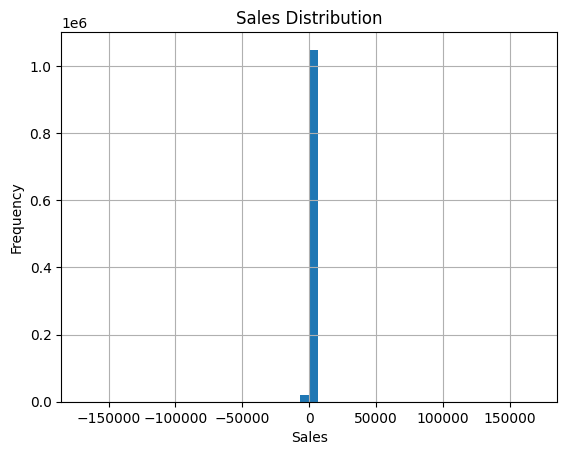

In [12]:
import matplotlib.pyplot as plt

df["Sales"].hist(bins=50)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Sales, dtype: float64


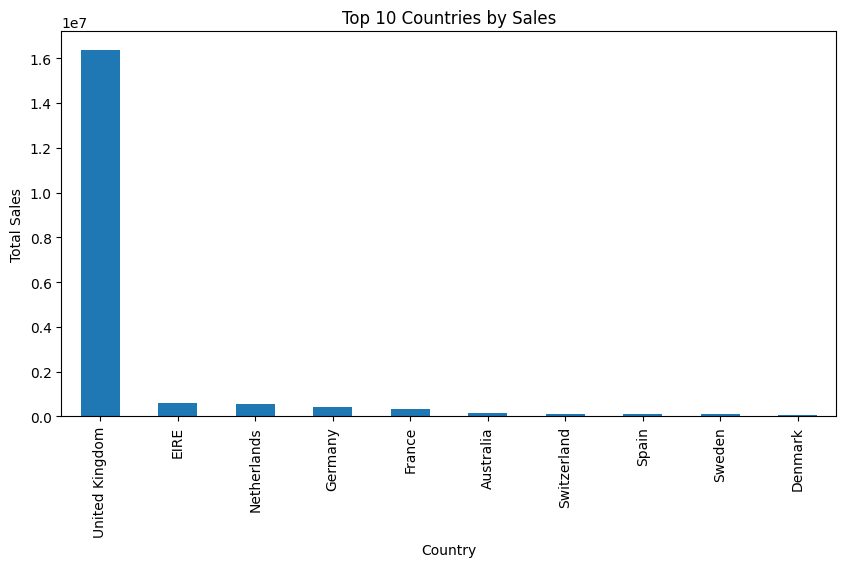

In [13]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

country_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Sales")
plt.ylabel("Total Sales")
plt.show()

In [14]:
df_clean = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

print("Original Shape:", df.shape)
print("Clean Shape:", df_clean.shape)

Original Shape: (1067371, 9)
Clean Shape: (1041671, 9)


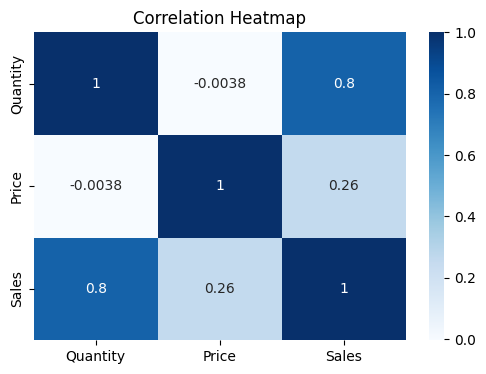

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df_clean[["Quantity", "Price", "Sales"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

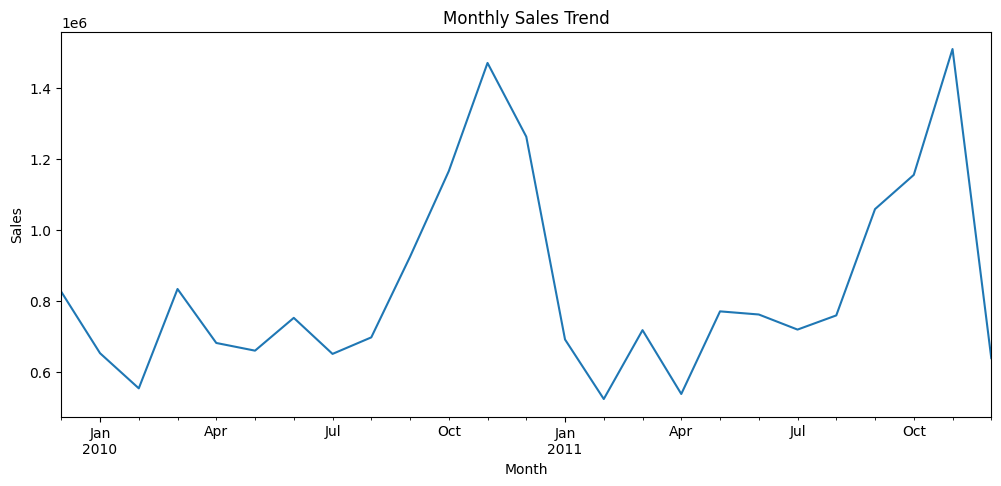

In [16]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

monthly_sales = (
    df_clean.groupby(
        df_clean["InvoiceDate"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [17]:
df_clean.to_csv(
    "../data/processed/cleaned_retail_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


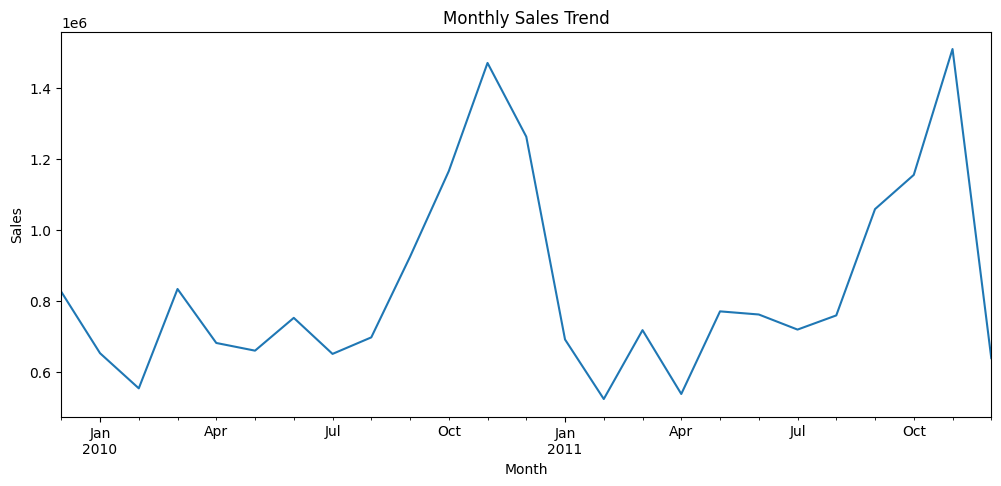

In [18]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"]
)

monthly_sales = (
    df_clean.groupby(
        df_clean["InvoiceDate"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [19]:
df_clean.to_csv(
    "cleaned_retail_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
